### Imports

In [1]:
import pickle
import os
import sys
import torch
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from torch.nn.functional import interpolate

In [2]:
sys.path.append('/home/omer/git/AutoDS3D')

In [3]:
from DS3Dplus.ds3d_utils import ImModel, Volume2XYZ

### Functions

In [4]:
import copy

def _compute_overlay(im, xyzps, param_dict):
    if xyzps is None or im is None:
        print('One of the inputs is empty.')
        return None, None, None, None
    xyz_rec = xyzps[:, :3]
    H, W = im.shape

    # deep copy to avoid mutating the original param_dict
    pd_local = copy.deepcopy(param_dict)
    pd_local['H'], pd_local['W'] = H, W

    if H > pd_local['phase_mask'].shape[0] or W > pd_local['phase_mask'].shape[1]:
        sf = max(H // pd_local['phase_mask'].shape[0] + 1, W // pd_local['phase_mask'].shape[1] + 1)
        pd_local['ps_BFP'] /= sf
        phase_mask = pd_local['phase_mask']
        HW = np.floor(pd_local['f_4f'] * pd_local['lamda'] / (
                pd_local['ps_camera'] * pd_local['ps_BFP']))
        HW = int(HW + 1 - (HW % 2))

        phase_mask = interpolate(torch.tensor(phase_mask).unsqueeze(0).unsqueeze(1), size=(HW, HW))
        pd_local['phase_mask'] = phase_mask[0, 0].numpy()

    model = ImModel(pd_local)

    # nphotons_rec = (pd_local['Nsig_range'][0]+pd_local['Nsig_range'][1])/2 * np.ones(xyz_rec.shape[0])
    # psfs_rec = model.get_psfs(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device)).cpu().numpy()
    im_norm = (im - im.min()) / (im.max() - im.min())

    ps_xy = pd_local['vs_xy'] * pd_local['us_factor']

    del model
    torch.cuda.empty_cache()

    return im_norm, xyz_rec, ps_xy


def select_strongest_localizations_by_radius(
    localizations,
    radius,
    x_col='x [nm]',
    y_col='y [nm]',
    intensity_col='intensity [au]',
):
    """Group nearby localizations in x/y and keep the strongest one per group."""
    if radius < 0:
        raise ValueError('radius must be non-negative.')

    if isinstance(localizations, pd.DataFrame):
        df = localizations.copy()
    else:
        df = pd.DataFrame(localizations)

    required_columns = [x_col, y_col, intensity_col]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    if df.empty:
        return df.iloc[0:0].copy()

    from scipy.spatial import cKDTree

    coords = df[[x_col, y_col]].to_numpy(dtype=np.float64)
    tree = cKDTree(coords)
    visited = np.zeros(len(df), dtype=bool)
    selected_indices = []

    for start_idx in range(len(df)):
        if visited[start_idx]:
            continue

        component = []
        stack = [start_idx]
        visited[start_idx] = True

        while stack:
            current_idx = stack.pop()
            component.append(current_idx)
            neighbor_indices = tree.query_ball_point(coords[current_idx], radius)

            for neighbor_idx in neighbor_indices:
                if not visited[neighbor_idx]:
                    visited[neighbor_idx] = True
                    stack.append(neighbor_idx)

        component_df = df.iloc[component]
        strongest_index = component_df[intensity_col].astype(float).idxmax()
        selected_indices.append(strongest_index)

    return df.loc[selected_indices].sort_index().reset_index(drop=True)


def bias_comparison(param_dict, xyzps_baseline, im_baseline, xyzps_corrected, im_corrected, device):
    im_b, xyz_b, ps_xy = _compute_overlay(im_baseline, xyzps_baseline, param_dict)
    im_c, xyz_c, ps_xy = _compute_overlay(im_corrected, xyzps_corrected, param_dict)

    fig, axes = plt.subplots(1, 2, figsize=(10, 10))

    axes[0].imshow(im_b, cmap='gray')
    axes[0].plot(xyz_b[:, 0] / (ps_xy*1000), xyz_b[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[0].set_title('Baseline')
    axes[0].axis('off')

    axes[1].imshow(im_c, cmap='gray')
    axes[1].plot(xyz_c[:, 0] / (ps_xy*1000), xyz_c[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[1].set_title('Corrected')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
def overlay_images_rg(im1: np.ndarray, im2: np.ndarray,
                      title: str = "",
                      figsize: tuple = (8, 8),
                      show: bool = True) -> np.ndarray:
    """Overlay two single-channel images with im1 in red and im2 in green.

    Each image is normalized independently to [0, 1] before compositing, so
    the dynamic range mismatch between channels does not hide structure.
    Pixels present in both images appear yellow; pixels unique to im1 appear
    red and pixels unique to im2 appear green.

    Args:
        im1: 2D array (H, W), shown as the red channel.
        im2: 2D array (H, W), shown as the green channel.
        title: Optional figure title.
        figsize: Matplotlib figure size in inches.
        show: If True, display the figure immediately.

    Returns:
        RGB overlay array of shape (H, W, 3), dtype float32, values in [0, 1].
    """
    def _norm(im):
        im = np.asarray(im, dtype=np.float32)
        lo, hi = im.min(), im.max()
        if hi > lo:
            return (im - lo) / (hi - lo)
        return np.zeros_like(im)

    r = _norm(im1)
    g = _norm(im2)
    rgb = np.stack([r, g, np.zeros_like(r)], axis=-1)

    if show:
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(rgb)
        if title:
            ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return rgb

In [6]:
from scipy.optimize import linear_sum_assignment


def match_localizations_hungarian(
    locs_a: np.ndarray,
    locs_b: np.ndarray,
    label_a: str = "Set A",
    label_b: str = "Set B",
    max_distance: float = np.inf,
    pixel_size_nm: float = None,
    figsize: tuple = (14, 10),
    xy_max: float = 1200
) -> dict:
    """Match two sets of 3D localizations with the Hungarian algorithm.

    Args:
        locs_a: Array (N, 3+), columns [x, y, z, ...] in nm.
        locs_b: Array (M, 3+), columns [x, y, z, ...] in nm.
        label_a: Legend label for the first set.
        label_b: Legend label for the second set.
        max_distance: Reject matched pairs with 3D distance above this (nm).
        pixel_size_nm: If provided, XY scatter is shown in pixels (divide nm
            coords by this value). Pass ps_xy * 1000 to match bias_comparison.
        figsize: Matplotlib figure size in inches.
    """
    a = np.asarray(locs_a, dtype=np.float64)[:, :3]
    b = np.asarray(locs_b, dtype=np.float64)[:, :3]

    diff = a[:, np.newaxis, :] - b[np.newaxis, :, :]
    cost = np.sqrt((diff ** 2).sum(axis=-1))

    row_idx, col_idx = linear_sum_assignment(cost)
    matched_3d = cost[row_idx, col_idx]

    keep = matched_3d <= max_distance
    row_idx, col_idx = row_idx[keep], col_idx[keep]

    d = a[row_idx] - b[col_idx]
    lateral_errors = np.sqrt(d[:, 0] ** 2 + d[:, 1] ** 2)
    depth_errors   = np.abs(d[:, 2])

    mean_lateral = float(lateral_errors.mean()) if len(lateral_errors) else np.nan
    mean_depth   = float(depth_errors.mean())   if len(depth_errors)   else np.nan

    print(f"Matched pairs : {len(row_idx)}")
    print(f"Mean lateral  : {mean_lateral:.2f} nm")
    print(f"Mean depth    : {mean_depth:.2f} nm")

    # convert to pixels for XY plot if pixel_size_nm is given
    scale = pixel_size_nm if pixel_size_nm is not None else 1.0
    xy_unit = 'pixels' if pixel_size_nm is not None else 'nm'
    ax_x = a[:, 0] / scale
    ax_y = a[:, 1] / scale
    bx_x = b[:, 0] / scale
    bx_y = b[:, 1] / scale

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

    ax_xy = fig.add_subplot(gs[0, :])
    ax_xy.scatter(ax_x, ax_y, s=12, c='tab:red',  alpha=0.7, label=label_a, zorder=3)
    ax_xy.scatter(bx_x, bx_y, s=12, c='tab:blue', alpha=0.7, label=label_b, zorder=3)
    # for r, c in zip(row_idx, col_idx):
    #     ax_xy.plot([ax_x[r], bx_x[c]], [ax_y[r], bx_y[c]],
    #                color='gray', lw=0.6, alpha=0.5)
    ax_xy.set_xlim(0, xy_max)
    ax_xy.set_ylim(0, xy_max)
    ax_xy.invert_yaxis()
    ax_xy.set_aspect('equal')
    ax_xy.set_xlabel(f'X ({xy_unit})')
    ax_xy.set_ylabel(f'Y ({xy_unit})')
    ax_xy.set_title('XY view — matched pairs')
    ax_xy.legend()

    ax_lat = fig.add_subplot(gs[1, 0])
    ax_lat.hist(lateral_errors, bins=30, color='tab:orange', edgecolor='k', linewidth=0.4)
    ax_lat.axvline(mean_lateral, color='k', linestyle='--', label=f'mean={mean_lateral:.1f} nm')
    ax_lat.set_xlabel('Lateral distance (nm)')
    ax_lat.set_ylabel('Count')
    ax_lat.set_title('Lateral error distribution')
    ax_lat.legend()

    ax_dep = fig.add_subplot(gs[1, 1])
    ax_dep.hist(depth_errors, bins=30, color='tab:purple', edgecolor='k', linewidth=0.4)
    ax_dep.axvline(mean_depth, color='k', linestyle='--', label=f'mean={mean_depth:.1f} nm')
    ax_dep.set_xlabel('Depth |ΔZ| (nm)')
    ax_dep.set_ylabel('Count')
    ax_dep.set_title('Depth error distribution')
    ax_dep.legend()

    plt.suptitle(
        f'{label_a} vs {label_b}  |  n={len(row_idx)}  |  '
        f'lateral={mean_lateral:.1f} nm  depth={mean_depth:.1f} nm',
        fontsize=11,
    )
    plt.show()

    return {
        'mean_lateral_nm': mean_lateral,
        'mean_depth_nm':   mean_depth,
        'n_matched':       len(row_idx),
        'lateral_errors':  lateral_errors,
        'depth_errors':    depth_errors,
        'row_idx':         row_idx,
        'col_idx':         col_idx,
    }


In [7]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def match_localizations_hungarian(locs_a, locs_b, max_distance=None):
    """Match two sets of localizations with the Hungarian algorithm and return mean distance.

    Args:
        locs_a: (N, D) array of localizations in nm.
        locs_b: (M, D) array of localizations in nm.
        max_distance: optional distance cutoff (nm); matched pairs beyond this are excluded.

    Returns:
        mean_dist: mean Euclidean distance of matched pairs in nm.
        dists: (K,) array of individual matched distances after filtering.
        row_ind: (K,) indices into locs_a for each matched pair.
        col_ind: (K,) indices into locs_b for each matched pair.
    """
    C = cdist(locs_a, locs_b, metric='euclidean')
    row_ind, col_ind = linear_sum_assignment(C)
    dists = C[row_ind, col_ind]
    if max_distance is not None:
        keep = dists <= max_distance
        row_ind, col_ind, dists = row_ind[keep], col_ind[keep], dists[keep]
    return float(np.mean(dists)), dists, row_ind, col_ind


In [8]:
def plot_lateral_error_vs_optical_distance(
    locs_eval: np.ndarray,
    lateral_errors: np.ndarray,
    col_idx: np.ndarray,
    optical_center: tuple = (647, 561),
    n_bins: int = 8,
    label: str = "",
    pixel_size_nm: float = None,
    figsize: tuple = (8, 6),
) -> None:
    """Plot lateral localization error and detection count vs distance from the optical axis.

    A single axes shows:
      - Bottom x-axis (blue): mean ± std lateral error per distance bin.
      - Top x-axis (orange): detection count per bin as horizontal bars (same y-axis).

    Parameters
    ----------
    locs_eval : (M, 2+) array
        Evaluated localizations in pixel coordinates [x, y, ...].
    lateral_errors : (K,) array
        Per-pair lateral errors from Hungarian matching (same units as locs_eval).
    col_idx : (K,) int array
        Indices into locs_eval for each matched pair.
    optical_center : (cx, cy)
        Optical axis center in pixel coordinates. Default (647, 561).
    n_bins : int
        Number of distance bins.
    label : str
        Optional figure title.
    pixel_size_nm : float, optional
        Pixel size in nm. If provided, axes are shown in nm instead of pixels.
    figsize : tuple
        Figure size in inches.
    """
    cx, cy = optical_center
    matched_locs = np.asarray(locs_eval)[col_idx]

    dists_to_center = np.sqrt(
        (matched_locs[:, 0] - cx) ** 2 + (matched_locs[:, 1] - cy) ** 2
    )

    bin_edges = np.linspace(0, dists_to_center.max() * 1.001, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    bin_indices = np.clip(np.digitize(dists_to_center, bin_edges) - 1, 0, n_bins - 1)

    mean_errors = np.full(n_bins, np.nan)
    std_errors = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        mask = bin_indices == b
        if mask.sum() > 0:
            mean_errors[b] = lateral_errors[mask].mean()
            std_errors[b] = lateral_errors[mask].std()
            counts[b] = mask.sum()

    scale = pixel_size_nm if pixel_size_nm is not None else 1.0
    unit = 'nm' if pixel_size_nm is not None else 'pixels'
    valid = ~np.isnan(mean_errors)

    fig, ax1 = plt.subplots(figsize=figsize)

    # Top x-axis: detection count bars (drawn first so they sit behind the error line)
    ax2 = ax1.twiny()
    ax2.barh(
        bin_centers[valid] * scale,
        counts[valid],
        height=bin_width * scale * 0.7,
        color='tab:orange', alpha=0.35, edgecolor='tab:orange', linewidth=0.5,
        label='detection count',
    )
    ax2.set_xlabel('Detection count', color='tab:orange')
    ax2.tick_params(axis='x', labelcolor='tab:orange')
    ax2.spines['top'].set_color('tab:orange')

    # Bottom x-axis: lateral error line + errorbars
    ax1.errorbar(
        mean_errors[valid] * scale,
        bin_centers[valid] * scale,
        xerr=std_errors[valid] * scale,
        fmt='o-', color='tab:blue', capsize=4, linewidth=1.5, markersize=5,
        label='mean ± std lateral error', zorder=3,
    )
    ax1.set_xlabel(f'Lateral error ({unit})', color='tab:blue')
    ax1.set_ylabel(f'Distance from optical axis ({unit})')
    ax1.tick_params(axis='x', labelcolor='tab:blue')
    ax1.spines['bottom'].set_color('tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Combined legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='lower right')

    if label:
        fig.suptitle(label, fontsize=11, y=1.02)

    plt.tight_layout()
    plt.show()


### Inputs

In [9]:
param_dict_path = '/home/omer/data/mse3/test_of_axis/nfp_minus3p5_z_0_to_3p2/train_data_120x120/param.pickle'

In [10]:
with open(param_dict_path, 'rb') as handle:
    param_dict = pickle.load(handle)

In [11]:
device = 'cuda:2'
param_dict['device'] = device
localization_th = 40 # nm
param_dict['threshold'] = 10
ps_xy = param_dict['vs_xy'] * param_dict['us_factor']

In [12]:
model = ImModel(param_dict)
volume2xyz = Volume2XYZ(param_dict)

In [13]:
baseline_dir = '/home/omer/data/mse3/train_data/baseline'
corrected_dir = '/home/omer/data/mse3/train_data/corrected'

In [14]:
import matplotlib.patches as mpatches
import numpy as np

def add_clipped_circle(ax, center, radius, img_shape, **patch_kwargs):
    """
    Draw a circle clipped to image dimensions.
    img_shape: (height, width) — as returned by im.shape[:2]
    """
    cx, cy = center
    h, w   = img_shape

    x0, x1 = cx - radius, cx + radius
    y0, y1 = cy - radius, cy + radius

    fully_inside = (x0 >= 0) and (x1 <= w) and (y0 >= 0) and (y1 <= h)
    fully_outside = (x1 < 0) or (x0 > w) or (y1 < 0) or (y0 > h)

    if fully_outside:
        return None  # nothing to draw

    if fully_inside:
        patch = mpatches.Circle(center, radius, **patch_kwargs)
    else:
        # Clip axes limits to image, the circle will be visually cropped
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)  # imshow y-axis is inverted
        patch = mpatches.Circle(center, radius, **patch_kwargs)

    ax.add_patch(patch)
    return patch

In [19]:
from DS3Dplus.ds3d_utils import calc_jaccard_rmse

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for frame_depth, frame in zip([3200, 2400,1600,800,0],['frame_0015', 'frame_0020', 'frame_0025', 'frame_0030', 'frame_0035']):
    print(f'Processing frame {frame} at depth {frame_depth} nm...')

    # 4f system
    frame_loc_csv_path_4f = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/4f_refrense/at4f_001_range10001_{frame}.csv"
    im_4f_path = f"/home/omer/experiments/mse3/at4f_001_range10001_frames/at4f_001_range10001_{frame}.tif"

    im_4f = tifffile.imread(im_4f_path)
    df_4f = pd.read_csv(frame_loc_csv_path_4f)
    df_filtered_4f = df_4f[(df_4f['z [nm]']>=(frame_depth - localization_th))&(df_4f['z [nm]']<=(frame_depth + localization_th))&(df_4f['intensity [au]']>=param_dict['threshold'])]
    df_filtered_4f.count()
    xyzps_4f = df_filtered_4f.to_numpy()[:, :4]
    z_errors_4f = np.abs(xyzps_4f[:, 2] - frame_depth)

    frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/orig/{frame}.csv"
    image_path = f"/home/omer/experiments/mse3/BehindObj_001_range10_frames/{frame}.tif"

    im_baseline = tifffile.imread(image_path) 

    df_baseline = pd.read_csv(frame_loc_csv_path)
    df_filtered_baseline = df_baseline[(df_baseline['z [nm]']>=(frame_depth - localization_th))&(df_baseline['z [nm]']<=(frame_depth + localization_th))&(df_baseline['intensity [au]']>=param_dict['threshold'])]
    df_filtered_baseline.count()
    xyzps_baseline = df_filtered_baseline.to_numpy()[:, :4]
    z_errors_baseline = np.mean(np.abs(xyzps_baseline[:, 2] - frame_depth))

    # corrected data
    corrected_image_path = f"/home/omer/training_results/mse3/beads/train_data_1200x1200/SFEnet_field_coord/2026-06-14_13-14-37/output/experiments/tiled_120/{frame}.tif"
    corrected_frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/field_coord/doda/{frame}.csv"

    im_corrected = tifffile.imread(corrected_image_path)

    df = pd.read_csv(corrected_frame_loc_csv_path)
    df_filtered = df[(df['z [nm]']>=(frame_depth - localization_th))&(df['z [nm]']<=(frame_depth + localization_th))&(df['intensity [au]']>=param_dict['threshold'])]
    df_filtered.count()
    xyzps = df_filtered.to_numpy()[:, :4]
    z_errors_corrected = np.mean(np.abs(xyzps[:, 2] - frame_depth))

    xyzps_4f_pixels = xyzps_4f[:, :2] / (ps_xy*1000)
    xyzps_baseline_pixels = xyzps_baseline[:, :2] / (ps_xy*1000)
    xyzps_corrected_pixels = xyzps[:, :2] / (ps_xy*1000)

    xyzps_4f_pixels[:, 0] -= 6
    xyzps_4f_pixels[:, 1] += 15

    ji_baseline, rmse_xy_baseline, _,_ = calc_jaccard_rmse(xyzps_4f[:,-1].reshape(-1,1), xyzps_baseline[:,-1].reshape(-1,1), radius=0.1)
    ji_corrected, rmse_xy_corrected, _,_ = calc_jaccard_rmse(xyzps_4f[:,-1].reshape(-1,1), xyzps[:,-1].reshape(-1,1), radius=0.1)

    avg_distance_4f_baseline, distances1, row_ind1, col_ind1 = match_localizations_hungarian(xyzps_4f_pixels, xyzps_baseline_pixels, max_distance=50)
    avg_distance_4f_corrected, distances2, row_ind2, col_ind2 = match_localizations_hungarian(xyzps_4f_pixels, xyzps_corrected_pixels, max_distance=50)

    dist_to_center_micron1 = np.sqrt((xyzps_baseline_pixels[col_ind1, 0] - 647)**2 + (xyzps_baseline_pixels[col_ind1, 1] - 561)**2)*ps_xy
    dist_to_center_micron2 = np.sqrt((xyzps_corrected_pixels[col_ind2, 0] - 647)**2 + (xyzps_corrected_pixels[col_ind2, 1] - 561)**2)*ps_xy


    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(im_baseline, cmap='gray')
    axes[0].plot(xyzps_baseline[:, 0] / (ps_xy*1000), xyzps_baseline[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[0].set_title('Baseline')
    axes[0].axis('off')
    axes[1].imshow(im_corrected, cmap='gray')
    axes[1].plot(xyzps[:, 0] / (ps_xy*1000), xyzps[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[1].set_title('Corrected')
    axes[1].axis('off')
    axes[2].imshow(im_4f, cmap='gray')
    axes[2].plot(xyzps_4f[:, 0] / (ps_xy*1000), xyzps_4f[:, 1] / (ps_xy*1000), 'r.', markersize=1)
    axes[2].set_title('4f system')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    fig,ax = plt.subplots(figsize=(8, 8))
    ax.scatter(647,561, s=12, c='black', label='Optical center', marker='+', zorder=4)
    ax.scatter(xyzps_4f_pixels[:, 0], xyzps_4f_pixels[:, 1], s=4, c='tab:green', label='4f system', zorder=3)
    ax.scatter(xyzps_baseline_pixels[:, 0], xyzps_baseline_pixels[:, 1], s=4, c='tab:red',  alpha=0.5, label='Baseline', zorder=3)
    ax.scatter(xyzps_corrected_pixels[:, 0], xyzps_corrected_pixels[:, 1], s=4, c='tab:blue', alpha=0.5, label='Corrected', zorder=3)
    ax.plot([],[],color='white', label=f'4f vs Baseline: {avg_distance_4f_baseline*(ps_xy*1000):.1f} nm', zorder=4) 
    ax.plot([],[],color='white', label=f'4f vs Corrected: {avg_distance_4f_corrected*(ps_xy*1000):.1f} nm', zorder=4) 
    ax.set_xlim(0, 1200)
    ax.set_ylim(0, 1200)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel(f'X (pixels)')
    ax.set_ylabel(f'Y (pixels)')
    ax.set_title(f'Frame {frame} at depth {frame_depth} nm')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- Jaccard index vs radius threshold ---
    r_max_px = max(distances1.max(), distances2.max())
    r_thresholds_px = np.linspace(0, r_max_px, 200)
    r_thresholds_nm = r_thresholds_px * ps_xy * 1000

    n_4f_j = len(xyzps_4f_pixels)
    n_baseline_j = len(xyzps_baseline_pixels)
    n_corrected_j = len(xyzps_corrected_pixels)

    def _jaccard_and_color(distances, dist_to_center, n_ref):
        jaccards, colors = [], []
        for r in r_thresholds_px:
            mask = distances <= r
            tp = int(np.sum(mask))
            denom = n_4f_j + n_ref - tp
            j = tp / denom if denom > 0 else 0.0
            c = float(np.mean(dist_to_center[mask])) if tp > 0 else np.nan
            jaccards.append(j)
            colors.append(c)
        return np.array(jaccards), np.array(colors)

    j_baseline, c_baseline = _jaccard_and_color(distances1, dist_to_center_micron1, n_baseline_j)
    j_corrected, c_corrected = _jaccard_and_color(distances2, dist_to_center_micron2, n_corrected_j)

    # Per-series color normalization
    vmin_b, vmax_b = float(np.nanmin(c_baseline)), float(np.nanmax(c_baseline))
    vmin_c, vmax_c = float(np.nanmin(c_corrected)), float(np.nanmax(c_corrected))

    cmap_obj = plt.cm.plasma
    col_b = cmap_obj(plt.Normalize(vmin_b, vmax_b)(float(np.nanmedian(c_baseline))))
    col_c = cmap_obj(plt.Normalize(vmin_c, vmax_c)(float(np.nanmedian(c_corrected))))
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='none',
               markerfacecolor=col_b, markeredgecolor=col_b, markersize=8, label='Baseline'),
        Line2D([0], [0], marker='x', linestyle='none',
               color=col_c, markersize=8, markeredgewidth=2, label='Corrected'),
    ]

    fig_j, ax_j = plt.subplots(figsize=(10, 5))

    sc1 = ax_j.scatter(r_thresholds_nm, j_baseline, c=c_baseline, cmap='plasma',
                        vmin=vmin_b, vmax=vmax_b, s=15, marker='o')
    sc2 = ax_j.scatter(r_thresholds_nm, j_corrected, c=c_corrected, cmap='plasma',
                        vmin=vmin_c, vmax=vmax_c, s=15, marker='x')

    ax_j.legend(handles=legend_handles)
    ax_j.set_xlabel('Radius threshold (nm)')
    ax_j.set_ylabel('Jaccard index')
    ax_j.grid(True, linestyle='--', alpha=0.5)

    cbar1 = fig_j.colorbar(sc1, ax=ax_j, fraction=0.046, pad=0.04)
    cbar1.set_label('Baseline: dist to center (μm)')
    cbar2 = fig_j.colorbar(sc2, ax=ax_j, fraction=0.046, pad=0.04)
    cbar2.set_label('Corrected: dist to center (μm)')

    fig_j.suptitle(f'Jaccard index vs radius threshold — Frame {frame} at {frame_depth} nm', fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"Frame {frame} at depth {frame_depth} nm:")
    print(f"Baseline: {len(xyzps_baseline)} localizations, mean Z error: {z_errors_baseline:.2f} nm")
    print(f"Corrected: {len(xyzps)} localizations, mean Z error: {z_errors_corrected:.2f} nm")
    print(f"4f system: {len(xyzps_4f)} localizations, mean Z error: {np.mean(np.abs(xyzps_4f[:, 2] - frame_depth)):.2f} nm")
    print(f"4f vs Baseline: {avg_distance_4f_baseline*(ps_xy*1000):.1f} nm")
    print(f"4f vs Corrected: {avg_distance_4f_corrected*(ps_xy*1000):.1f} nm")

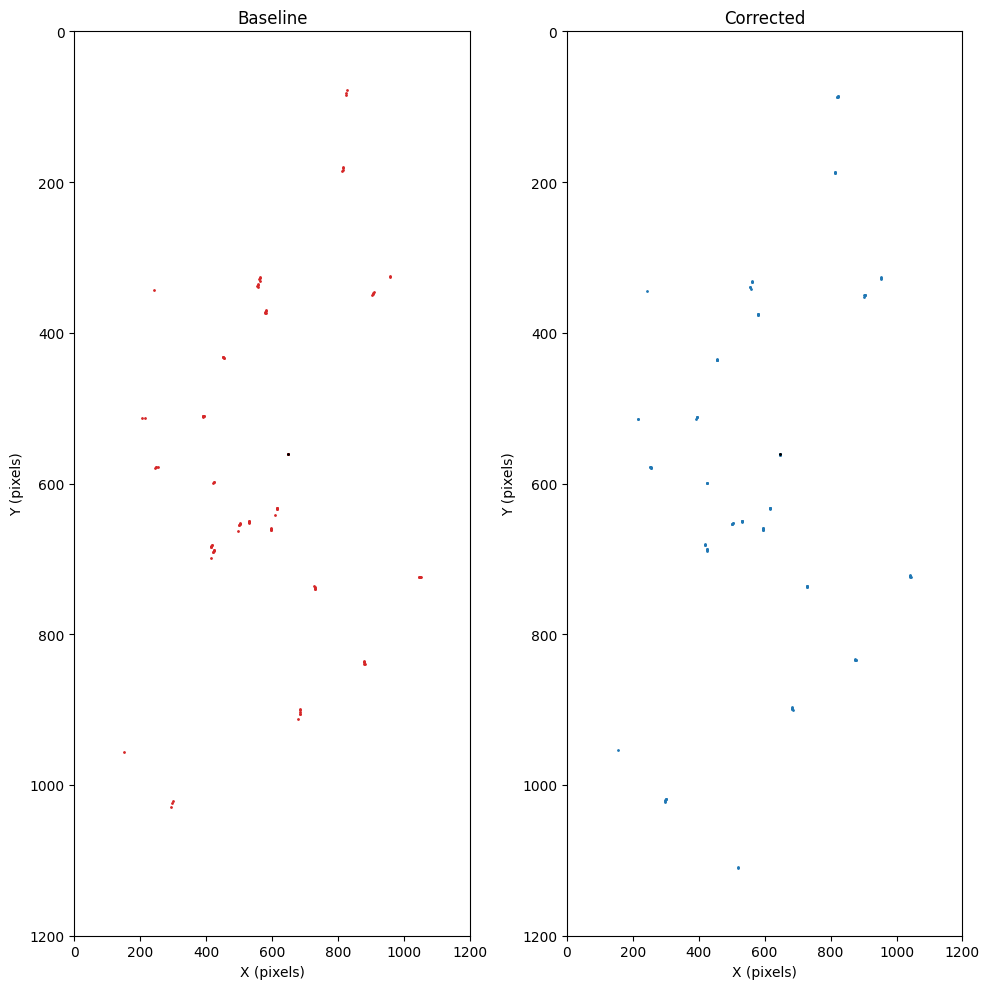

In [16]:
df_orig_all = pd.DataFrame()
df_corrected_all = pd.DataFrame()
# XY correction as a function of Z
for frame_depth, frame in zip([3200, 2400,1600,800,0],['frame_0015', 'frame_0020', 'frame_0025', 'frame_0030', 'frame_0035']):
    ## original data
    frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/photon_count_alignment/orig/{frame}.csv"
    # corrected data
    corrected_frame_loc_csv_path = f"/home/omer/git/AutoDS3D/train_results/mse3/nfp_minus_3p5_z_0_to_3p2/field_coord/doda/{frame}.csv"

    df_orig = pd.read_csv(frame_loc_csv_path)
    df_orig = df_orig[(df_orig['z [nm]']>=(frame_depth - localization_th))&(df_orig['z [nm]']<=(frame_depth + localization_th))&(df_orig['intensity [au]']>=param_dict['threshold'])]
    df_orig_all = pd.concat([df_orig_all, df_orig], ignore_index=True)

    df_corrected = pd.read_csv(corrected_frame_loc_csv_path)
    df_corrected = df_corrected[(df_corrected['z [nm]']>=(frame_depth - localization_th))&(df_corrected['z [nm]']<=(frame_depth + localization_th))&(df_corrected['intensity [au]']>=param_dict['threshold'])]
    
    df_corrected_all = pd.concat([df_corrected_all, df_corrected], ignore_index=True)

xyzps_orig = df_orig_all.to_numpy()[:, :4]
xyzps_orig[:,0] = xyzps_orig[:,0] / (ps_xy*1000)
xyzps_orig[:,1] = xyzps_orig[:,1] / (ps_xy*1000)

xyzps_corrected = df_corrected_all.to_numpy()[:, :4]
xyzps_corrected[:,0] = xyzps_corrected[:,0] / (ps_xy*1000)
xyzps_corrected[:,1] = xyzps_corrected[:,1] / (ps_xy*1000)

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].scatter(xyzps_orig[:, 0], xyzps_orig[:, 1], s=1, c='tab:red', label='Baseline')
axes[0].set_title('Baseline')
axes[0].set_xlabel('X (pixels)')
axes[0].set_ylabel('Y (pixels)')
axes[0].set_xlim(0, 1200)
axes[0].set_ylim(0, 1200)
axes[0].scatter(647,561, s=1, c='cyan', label='Reference point', edgecolors='k', marker='X')
axes[0].invert_yaxis()
axes[1].scatter(xyzps_corrected[:, 0], xyzps_corrected[:, 1], s=1, c='tab:blue', label='Corrected')
axes[1].set_title('Corrected')
axes[1].set_xlabel('X (pixels)')
axes[1].set_ylabel('Y (pixels)')
axes[1].set_xlim(0, 1200)
axes[1].set_ylim(0, 1200)
axes[1].scatter(647,561, s=1, c='cyan', label='Reference point', edgecolors='k', marker='X')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [17]:
# Release GPU memory
if 'model' in locals():
    del model
if 'volume2xyz' in locals():
    del volume2xyz
import gc
torch.cuda.empty_cache()
gc.collect()

6832